# NYC Airbnb  Text Feature Extraction
**DATASCI 347: Machine Learning · Spring 2026**  
Input: `AB_NYC_2019_clean.csv` · Column: `name` (listing description)  
Output: `AB_NYC_2019_text_features.csv`

---

## 0 · Imports & Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from scipy.stats import mannwhitneyu, pearsonr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud, STOPWORDS

# ── Plot style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F9F9F9',
    'axes.edgecolor':    '#CCCCCC',
    'axes.labelcolor':   '#1A1A2E',
    'axes.titlecolor':   '#1A1A2E',
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'xtick.color':       '#1A1A2E',
    'ytick.color':       '#1A1A2E',
    'grid.color':        '#E5E7EB',
    'grid.linewidth':    0.5,
    'text.color':        '#1A1A2E',
    'font.family':       'monospace',
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#CCCCCC',
    'legend.fontsize':   9,
})

ACCENT  = '#e8c547'
ACCENT2 = '#c8773a'
ACCENT3 = '#6bbfa0'
ACCENT4 = '#7b9cce'
DANGER  = '#c45c5c'
MUTED   = '#7a7870'

print("Libraries loaded ✓")

Libraries loaded ✓


---
## 1 · Load Clean Data

In [6]:
df = pd.read_csv('data/AB_NYC_2019_clean.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\n'name' missing: {df['name'].isnull().sum()} rows")

# Fill the 16 missing names with empty string (negligible; won't affect results)
df['name'] = df['name'].fillna('').str.strip().str.lower()

print(f"\nSample descriptions:")
for n in df['name'].sample(8, random_state=42):
    print(f"  '{n}'"  )

Shape: (48870, 13)
Columns: ['name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'log_price']

'name' missing: 15 rows

Sample descriptions:
  'furnished br in a 2br apt gramercy'
  'sunny & spacious upper west side one bedroom apt'
  'east 29th street, luxury studio in nomad'
  'king bed, super host, near central/riverside parks'
  'spacious and quiet manhattan harlem 1-bed apt!'
  'sunny bedroom steps to subway & central park'
  'entire 3rd floor of brownstone at prospect park!'
  'your own entire private place in brooklyn ny :)'


---
## 2 · Basic Text Statistics

In [7]:
# Word count and character count
df['desc_word_count'] = df['name'].apply(lambda x: len(x.split()))
df['desc_char_count'] = df['name'].apply(len)

print("=== Word count distribution ===")
print(df['desc_word_count'].describe().round(2))
print(f"\nListings with 0 words (empty name): {(df['desc_word_count'] == 0).sum()}")

=== Word count distribution ===
count    48870.00
mean         6.11
std          2.02
min          0.00
25%          5.00
50%          6.00
75%          7.00
max         29.00
Name: desc_word_count, dtype: float64

Listings with 0 words (empty name): 15


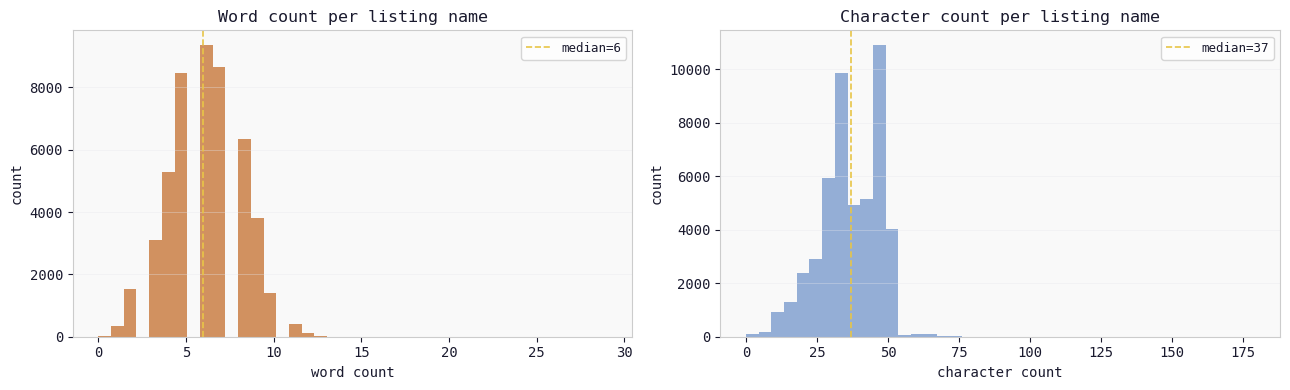

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(df['desc_word_count'], bins=40, color=ACCENT2, alpha=0.8, edgecolor='none')
ax.set_title('Word count per listing name')
ax.set_xlabel('word count')
ax.set_ylabel('count')
ax.grid(axis='y', alpha=0.5)
ax.axvline(df['desc_word_count'].median(), color=ACCENT, linewidth=1.2,
           linestyle='--', label=f"median={df['desc_word_count'].median():.0f}")
ax.legend()

ax = axes[1]
ax.hist(df['desc_char_count'], bins=40, color=ACCENT4, alpha=0.8, edgecolor='none')
ax.set_title('Character count per listing name')
ax.set_xlabel('character count')
ax.set_ylabel('count')
ax.grid(axis='y', alpha=0.5)
ax.axvline(df['desc_char_count'].median(), color=ACCENT, linewidth=1.2,
           linestyle='--', label=f"median={df['desc_char_count'].median():.0f}")
ax.legend()

plt.tight_layout()
plt.savefig('figures/fig_text_length.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 3 · Word Frequency Analysis

In [9]:
# Custom stopwords: standard English + Airbnb-generic terms that carry no pricing signal
custom_stops = STOPWORDS | {
    'room', 'apt', 'apartment', 'new', 'york', 'nyc', 'ny', 'brooklyn',
    'manhattan', 'queens', 'bronx', 'home', 'house', 'place', 'space',
    'in', 'the', 'a', 'an', 'to', 'and', 'with', 'near', 'for', 'of',
    'your', 'our', 'my', 'is', 'at', 'on', 'great', 'amazing', 'beautiful',
    '1', '2', '3', '4', '5'
}

all_words = []
for name in df['name']:
    words = re.findall(r'[a-z]+', name)
    all_words.extend([w for w in words if w not in custom_stops and len(w) > 2])

word_freq = Counter(all_words)
top50 = word_freq.most_common(50)

print("Top 50 words (after stopword removal):")
for i, (word, count) in enumerate(top50):
    print(f"  {i+1:>2}. {word:<20} {count:>6,}")

Top 50 words (after stopword removal):
   1. bedroom               8,305
   2. private               7,411
   3. cozy                  5,100
   4. studio                4,108
   5. spacious              3,794
   6. park                  3,165
   7. east                  3,109
   8. sunny                 2,944
   9. williamsburg          2,742
  10. village               2,345
  11. bed                   2,218
  12. loft                  2,099
  13. large                 2,083
  14. heart                 2,071
  15. modern                1,820
  16. central               1,817
  17. bright                1,724
  18. luxury                1,712
  19. location              1,621
  20. west                  1,600
  21. bushwick              1,438
  22. side                  1,434
  23. charming              1,388
  24. upper                 1,357
  25. one                   1,338
  26. midtown               1,294
  27. min                   1,277
  28. quiet                 1,250
  29. bat

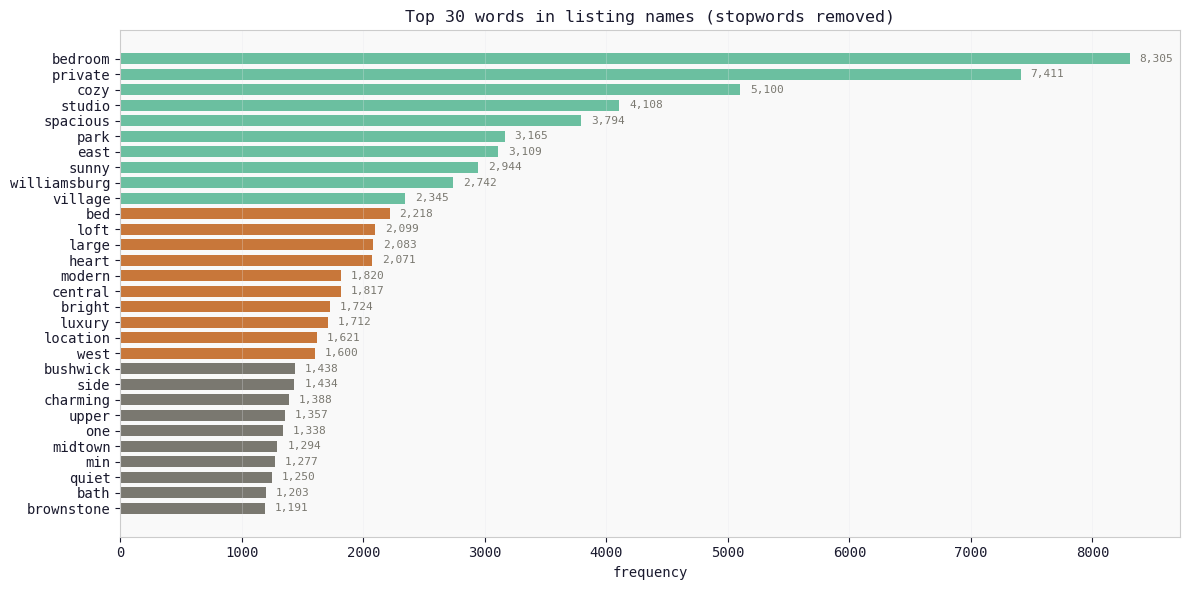

In [10]:
# ── Top 30 bar chart ──────────────────────────────────────────────────────
top30 = top50[:30]
words_30  = [w for w, _ in top30]
counts_30 = [c for _, c in top30]

fig, ax = plt.subplots(figsize=(12, 6))
colors = [ACCENT3 if i < 10 else ACCENT2 if i < 20 else MUTED for i in range(30)]
ax.barh(words_30[::-1], counts_30[::-1], color=colors[::-1], edgecolor='none', height=0.7)
ax.set_title('Top 30 words in listing names (stopwords removed)')
ax.set_xlabel('frequency')
ax.grid(axis='x', alpha=0.4)
for i, (w, c) in enumerate(zip(words_30[::-1], counts_30[::-1])):
    ax.text(c + 80, i, f'{c:,}', va='center', fontsize=8, color=MUTED)

plt.tight_layout()
plt.savefig('figures/fig_word_frequency.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

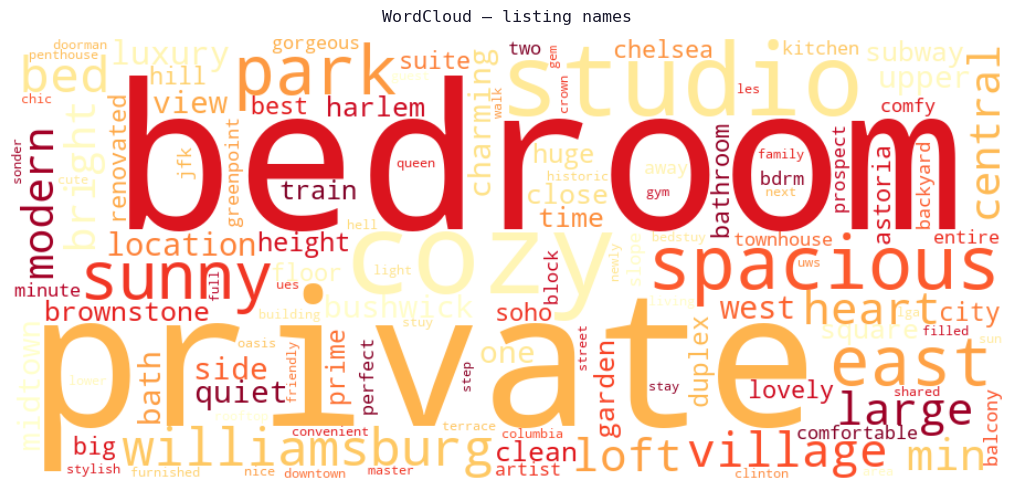

In [11]:
# ── WordCloud ─────────────────────────────────────────────────────────────
wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='YlOrRd',
    stopwords=custom_stops,
    max_words=120,
    prefer_horizontal=0.85,
    collocations=False
).generate(' '.join(all_words))

fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — listing names', pad=12)
plt.tight_layout()
plt.savefig('figures/fig_wordcloud.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 4 · Keyword Feature Extraction

Each feature is a binary flag (0/1) extracted via regex from the lowercased listing name.  
`bedroom_count` is a continuous variable (integer extracted from text, e.g. "2BR", "3 bed").  
`desc_word_count` is carried forward from §2.

In [12]:
def flag(pattern, series):
    """Return binary Series: 1 if pattern found in name, else 0."""
    return series.str.contains(pattern, regex=True, na=False).astype(int)

# ── Binary keyword flags ──────────────────────────────────────────────────
df['kw_luxury']    = flag(r'luxury|luxe|elegant|upscale|deluxe|high.end|premium', df['name'])
df['kw_cozy']      = flag(r'cozy|cosy|charming|warm|cute|quaint',                 df['name'])
df['kw_private']   = flag(r'private',                                              df['name'])
df['kw_studio']    = flag(r'studio',                                               df['name'])
df['kw_loft']      = flag(r'loft',                                                 df['name'])
df['kw_sunny']     = flag(r'sunny|bright|sun.?filled|sun.?drenched',               df['name'])
df['kw_spacious']  = flag(r'spacious|large|huge|big|roomy',                        df['name'])
df['kw_views']     = flag(r'view|skyline|central.?park|river|park.?view',          df['name'])
df['kw_transport'] = flag(r'subway|metro|transit|jfk|lga|airport|train',           df['name'])
df['kw_entire']    = flag(r'entire|whole|full',                                    df['name'])
df['kw_renovated'] = flag(r'renovat|modern|new|updated|remodel',                   df['name'])
df['kw_suite']     = flag(r'suite',                                                df['name'])

# ── Bedroom count extraction ──────────────────────────────────────────────
def extract_bedroom_count(text):
    """
    Extract bedroom count from text.
    Patterns: '2BR', '2 br', '2 bed', '2 bedroom', 'two bedroom'
    Returns NaN if not found.
    """
    num_map = {'one':1,'two':2,'three':3,'four':4,'five':5,'six':6}

    # Numeric: '2br', '2 br', '2bed', '2 bed', '2bedroom', '2 bedroom'
    m = re.search(r'(\d+)\s*(?:br|bed(?:room)?s?)', text)
    if m:
        n = int(m.group(1))
        return n if 1 <= n <= 10 else np.nan

    # Written: 'two bedroom', 'three bed'
    for word, val in num_map.items():
        if re.search(rf'{word}\s*(?:br|bed(?:room)?s?)', text):
            return val
    return np.nan

df['bedroom_count'] = df['name'].apply(extract_bedroom_count)

# Summary
kw_cols = [c for c in df.columns if c.startswith('kw_')]
print("=== Keyword flag prevalence ===")
for col in kw_cols:
    n = df[col].sum()
    pct = n / len(df) * 100
    print(f"  {col:<20} {n:>6,}  ({pct:>5.1f}%)")

print(f"\n  bedroom_count extracted: {df['bedroom_count'].notna().sum():,} "
      f"({df['bedroom_count'].notna().mean()*100:.1f}%)")
print(f"  bedroom_count distribution:")
print(df['bedroom_count'].value_counts().sort_index().to_string())

=== Keyword flag prevalence ===
  kw_luxury             2,114  (  4.3%)
  kw_cozy               7,254  ( 14.8%)
  kw_private            7,316  ( 15.0%)
  kw_studio             4,130  (  8.5%)
  kw_loft               2,177  (  4.5%)
  kw_sunny              4,965  ( 10.2%)
  kw_spacious           7,503  ( 15.4%)
  kw_views              2,821  (  5.8%)
  kw_transport          3,019  (  6.2%)
  kw_entire             1,259  (  2.6%)
  kw_renovated          4,068  (  8.3%)
  kw_suite                795  (  1.6%)

  bedroom_count extracted: 9,390 (19.2%)
  bedroom_count distribution:
bedroom_count
1.0     4990
2.0     3056
3.0      946
4.0      230
5.0      122
6.0       23
7.0       15
8.0        3
9.0        2
10.0       3


---
## 5 · Statistical Tests — Do Keywords Predict log(price)?

**Mann-Whitney U test** (non-parametric):  
H₀: listings with keyword X have the same log(price) distribution as those without.  
Preferred over t-test because we cannot assume equal variances between groups.

In [13]:
results = []
for col in kw_cols:
    has    = df[df[col] == 1]['log_price']
    has_not = df[df[col] == 0]['log_price']
    if len(has) < 10:
        continue
    U, p = mannwhitneyu(has, has_not, alternative='two-sided')
    mean_diff = has.mean() - has_not.mean()
    results.append({
        'keyword':   col.replace('kw_', ''),
        'n_with':    len(has),
        'mean_with': round(has.mean(), 3),
        'mean_without': round(has_not.mean(), 3),
        'mean_diff_log': round(mean_diff, 3),
        'pct_price_diff': round((np.exp(mean_diff) - 1) * 100, 1),
        'U':         round(U, 0),
        'p_value':   round(p, 6),
        'significant': p < 0.05
    })

mw_df = pd.DataFrame(results).sort_values('mean_diff_log', ascending=False)
print(mw_df.to_string(index=False))

  keyword  n_with  mean_with  mean_without  mean_diff_log  pct_price_diff           U  p_value  significant
   luxury    2114      5.241         4.704          0.537            71.1  70498412.0 0.000000         True
     loft    2177      5.050         4.712          0.338            40.2  64037886.0 0.000000         True
    views    2821      4.985         4.711          0.274            31.5  80210985.0 0.000000         True
    suite     795      4.958         4.723          0.235            26.5  21957961.0 0.000000         True
   studio    4130      4.887         4.712          0.175            19.1 110309928.0 0.000000         True
   entire    1259      4.886         4.723          0.163            17.7  34517101.0 0.000000         True
renovated    4068      4.860         4.715          0.145            15.6 103128468.0 0.000000         True
 spacious    7503      4.708         4.731         -0.023            -2.2 153054253.0 0.057631        False
    sunny    4965      4.637

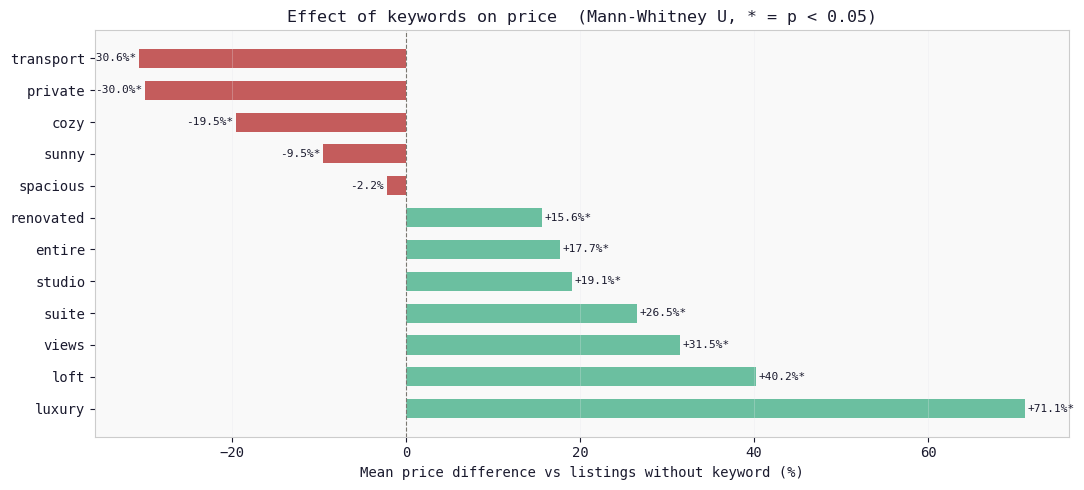


* = statistically significant at p < 0.05 (Mann-Whitney U, two-sided)


In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = [ACCENT3 if d > 0 else DANGER for d in mw_df['mean_diff_log']]
bars = ax.barh(mw_df['keyword'], mw_df['pct_price_diff'],
               color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean price difference vs listings without keyword (%)')
ax.set_title('Effect of keywords on price  (Mann-Whitney U, * = p < 0.05)')
ax.grid(axis='x', alpha=0.4)

for bar, row in zip(bars, mw_df.itertuples()):
    sig = '*' if row.significant else ''
    x = bar.get_width()
    ax.text(x + (0.3 if x >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{row.pct_price_diff:+.1f}%{sig}',
            va='center', ha='left' if x >= 0 else 'right',
            fontsize=8, color='#1A1A2E')

plt.tight_layout()
plt.savefig('figures/fig_keyword_effects.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n* = statistically significant at p < 0.05 (Mann-Whitney U, two-sided)")

Pearson r(bedroom_count, log_price): +0.2717, p=0.0000


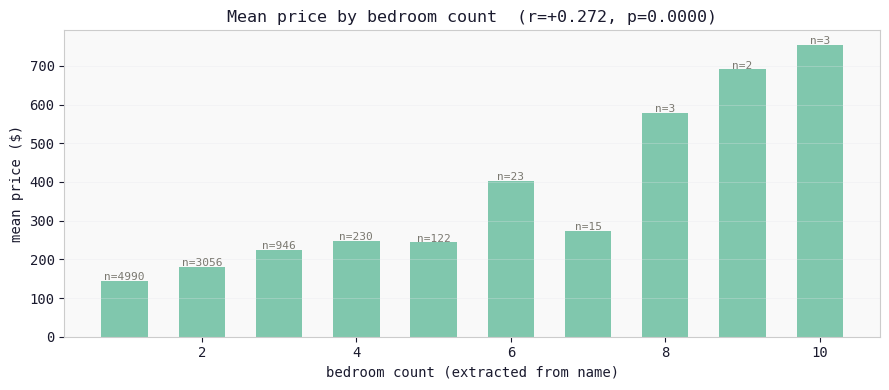

In [15]:
# ── bedroom_count vs log(price) ───────────────────────────────────────────
bed_df = df[df['bedroom_count'].notna()].copy()
bed_df['bedroom_count'] = bed_df['bedroom_count'].astype(int)

r_bed, p_bed = pearsonr(bed_df['bedroom_count'], bed_df['log_price'])
print(f"Pearson r(bedroom_count, log_price): {r_bed:+.4f}, p={p_bed:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
bed_means = bed_df.groupby('bedroom_count')['log_price'].agg(['mean','std','count'])
ax.bar(bed_means.index, np.exp(bed_means['mean']),
       color=ACCENT3, edgecolor='none', width=0.6, alpha=0.85)
ax.set_xlabel('bedroom count (extracted from name)')
ax.set_ylabel('mean price ($)')
ax.set_title(f'Mean price by bedroom count  (r={r_bed:+.3f}, p={p_bed:.4f})')
ax.grid(axis='y', alpha=0.4)
for x, row in bed_means.iterrows():
    ax.text(x, np.exp(row['mean']) + 2, f"n={int(row['count'])}",
            ha='center', fontsize=8, color=MUTED)

plt.tight_layout()
plt.savefig('figures/fig_bedroom_price.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 6 · TF-IDF Vectorisation + PCA

**Why TF-IDF here:**  
Keyword flags capture pre-specified patterns, but may miss emergent vocabulary.  
TF-IDF treats each word's relative importance across the corpus and can surface  
terms we didn't think to hard-code.

**Why PCA after TF-IDF:**  
The TF-IDF matrix is high-dimensional and sparse. PCA compresses it into dense  
components that linear models can consume directly.

> ⚠ **Leakage note:** In the modelling phase, TfidfVectorizer and PCA must be  
> fit **inside each CV fold** on training data only, then applied to validation data.  
> Here we fit on the full dataset for exploratory purposes only.

In [16]:
# ── TF-IDF ────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=200,        # top 200 terms by corpus TF-IDF score
    min_df=20,               # ignore terms in fewer than 20 listings
    max_df=0.85,             # ignore terms in >85% of listings (too generic)
    stop_words='english',
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True        # log(1 + tf) instead of raw tf
)

tfidf_matrix = tfidf.fit_transform(df['name'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size:     {len(tfidf.vocabulary_)}")
print(f"\nTop 30 terms by mean TF-IDF score:")
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:30]
vocab_inv = {v: k for k, v in tfidf.vocabulary_.items()}
for i, idx in enumerate(top_idx):
    print(f"  {i+1:>2}. {vocab_inv[idx]:<25} {mean_tfidf[idx]:.5f}")

TF-IDF matrix shape: (48870, 200)
Vocabulary size:     200

Top 30 terms by mean TF-IDF score:
   1. room                      0.06636
   2. bedroom                   0.05511
   3. apartment                 0.05062
   4. private                   0.04825
   5. brooklyn                  0.03935
   6. cozy                      0.03890
   7. apt                       0.03568
   8. studio                    0.03543
   9. manhattan                 0.03170
  10. spacious                  0.03151
  11. williamsburg              0.02735
  12. sunny                     0.02529
  13. private room              0.02513
  14. east                      0.02452
  15. park                      0.02395
  16. beautiful                 0.02392
  17. nyc                       0.02260
  18. loft                      0.02197
  19. village                   0.02035
  20. home                      0.01967
  21. near                      0.01963
  22. large                     0.01905
  23. heart              

In [17]:
# ── PCA on TF-IDF ─────────────────────────────────────────────────────────
# Standardise first (TF-IDF values are already in [0,1] but variances differ)
X_tfidf_dense = tfidf_matrix.toarray()
scaler_tfidf  = StandardScaler(with_mean=False)  # sparse-safe: don't center
X_tfidf_scaled = scaler_tfidf.fit_transform(X_tfidf_dense)

# Fit PCA to find how many components explain ≥ 80% variance
pca_full = PCA(random_state=42)
pca_full.fit(X_tfidf_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
k80 = np.searchsorted(cumvar, 0.80) + 1
k90 = np.searchsorted(cumvar, 0.90) + 1
print(f"Components to explain 80% variance: {k80}")
print(f"Components to explain 90% variance: {k90}")

Components to explain 80% variance: 128
Components to explain 90% variance: 151


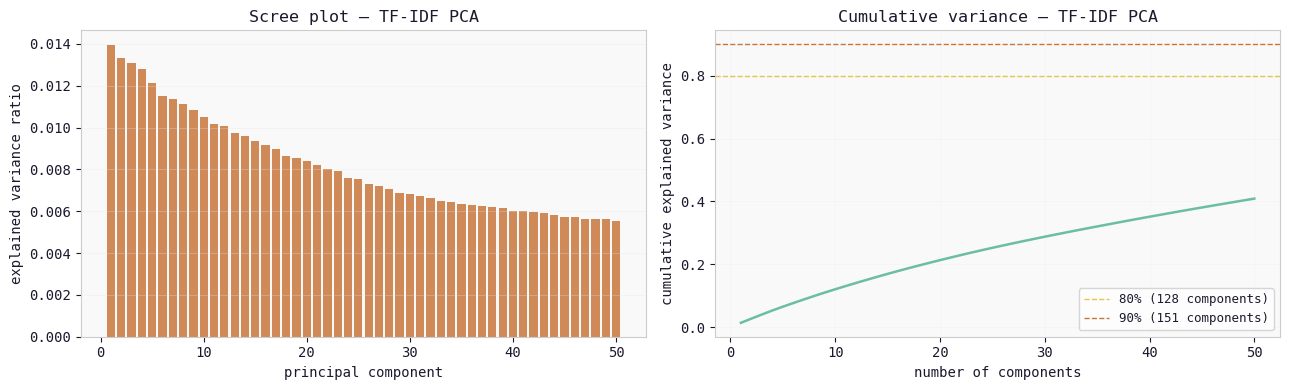

In [18]:
# ── Scree plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

n_show = 50
ax = axes[0]
ax.bar(range(1, n_show+1), pca_full.explained_variance_ratio_[:n_show],
       color=ACCENT2, edgecolor='none', alpha=0.85)
ax.set_xlabel('principal component')
ax.set_ylabel('explained variance ratio')
ax.set_title('Scree plot — TF-IDF PCA')
ax.grid(axis='y', alpha=0.4)

ax = axes[1]
ax.plot(range(1, n_show+1), cumvar[:n_show], color=ACCENT3, linewidth=1.8)
ax.axhline(0.80, color=ACCENT,  linewidth=1, linestyle='--', label=f'80% ({k80} components)')
ax.axhline(0.90, color=ACCENT2, linewidth=1, linestyle='--', label=f'90% ({k90} components)')
ax.set_xlabel('number of components')
ax.set_ylabel('cumulative explained variance')
ax.set_title('Cumulative variance — TF-IDF PCA')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_pca_scree.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

PCA output shape: (48870, 128)
Total variance explained: 0.802


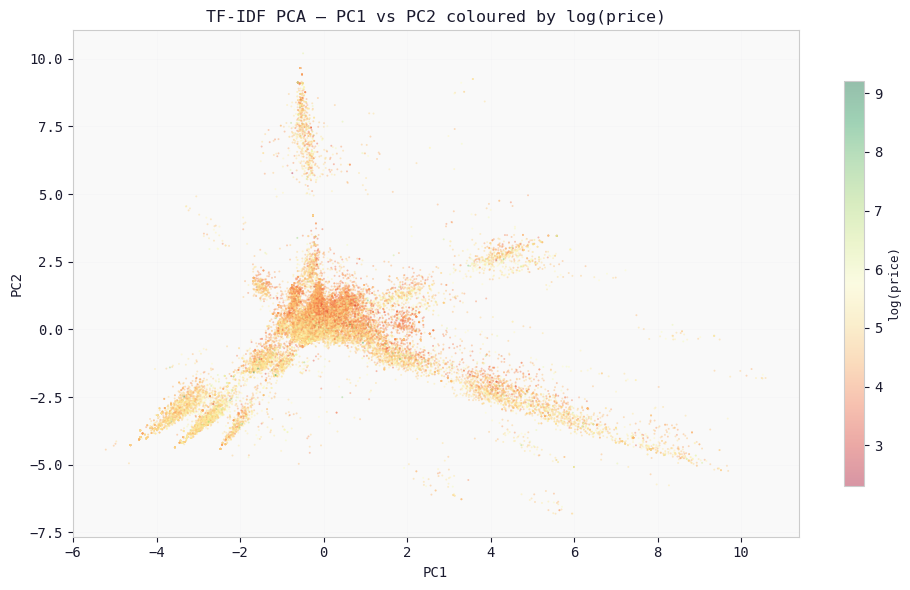

In [19]:
# ── Fit final PCA with k80 components ─────────────────────────────────────
pca = PCA(n_components=k80, random_state=42)
X_pca = pca.fit_transform(X_tfidf_scaled)
print(f"PCA output shape: {X_pca.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

# ── PC1 vs PC2 scatter, coloured by log(price) ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=df['log_price'], cmap='RdYlGn',
                s=2, alpha=0.4, linewidths=0)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('log(price)', fontsize=9)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('TF-IDF PCA — PC1 vs PC2 coloured by log(price)')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('figures/fig_pca_scatter.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [20]:
# ── Correlation of each PC with log(price) ────────────────────────────────
print("Pearson r — each PC vs log(price):")
pc_corrs = []
for i in range(min(10, k80)):
    r, p = pearsonr(X_pca[:, i], df['log_price'])
    pc_corrs.append({'PC': f'PC{i+1}', 'r': round(r, 4), 'p': round(p, 6),
                     'sig': '*' if p < 0.05 else ''})
    print(f"  PC{i+1}: r={r:+.4f}, p={p:.4f} {pc_corrs[-1]['sig']}")

Pearson r — each PC vs log(price):
  PC1: r=-0.0243, p=0.0000 *
  PC2: r=-0.1284, p=0.0000 *
  PC3: r=+0.2450, p=0.0000 *
  PC4: r=+0.0732, p=0.0000 *
  PC5: r=+0.1639, p=0.0000 *
  PC6: r=+0.1223, p=0.0000 *
  PC7: r=+0.0360, p=0.0000 *
  PC8: r=+0.0680, p=0.0000 *
  PC9: r=-0.1065, p=0.0000 *
  PC10: r=-0.0637, p=0.0000 *


---
## 7 · Assemble & Export Text Features

In [21]:
# ── Assemble all text features ────────────────────────────────────────────
text_features = df[['desc_word_count'] + kw_cols + ['bedroom_count']].copy()

# Add PCA components
pca_cols = [f'tfidf_pc{i+1}' for i in range(k80)]
pca_df   = pd.DataFrame(X_pca, columns=pca_cols, index=df.index)
text_features = pd.concat([text_features, pca_df], axis=1)

print(f"Text feature matrix shape: {text_features.shape}")
print(f"\nFeatures included:")
print(f"  Continuous:  desc_word_count, bedroom_count")
print(f"  Binary flags: {len(kw_cols)} keyword flags")
print(f"  TF-IDF PCA:  {k80} principal components (≥80% variance)")
print(f"\nMissing values:")
print(text_features.isnull().sum()[text_features.isnull().sum() > 0])

Text feature matrix shape: (48870, 142)

Features included:
  Continuous:  desc_word_count, bedroom_count
  Binary flags: 12 keyword flags
  TF-IDF PCA:  128 principal components (≥80% variance)

Missing values:
bedroom_count    39480
dtype: int64


In [22]:
# bedroom_count: fill NaN with median (listings where count not mentioned)
bedroom_median = text_features['bedroom_count'].median()
text_features['bedroom_count'] = text_features['bedroom_count'].fillna(bedroom_median)
print(f"bedroom_count NaN filled with median: {bedroom_median}")

# Export
text_features.to_csv('data/AB_NYC_2019_text_features.csv', index=False)
print(f"\nExported AB_NYC_2019_text_features.csv")
print(f"Shape: {text_features.shape}")
print(f"\nFirst 3 rows:")
text_features.head(3)

bedroom_count NaN filled with median: 1.0

Exported AB_NYC_2019_text_features.csv
Shape: (48870, 142)

First 3 rows:


,desc_word_count,kw_luxury,kw_cozy,kw_private,kw_studio,kw_loft,kw_sunny,kw_spacious,kw_views,kw_transport,...,tfidf_pc119,tfidf_pc120,tfidf_pc121,tfidf_pc122,tfidf_pc123,tfidf_pc124,tfidf_pc125,tfidf_pc126,tfidf_pc127,tfidf_pc128
0,8,0,0,0,0,0,0,0,0,0,...,0.359947,-0.399477,0.424015,-0.090638,0.949497,0.757115,0.411869,-0.521683,-0.312683,0.082625
1,3,0,0,0,0,0,0,0,0,0,...,-0.131659,-0.191006,0.240063,-1.516985,-0.185130,0.960651,-1.020463,-0.543522,1.294107,-0.389438
2,6,0,0,0,0,0,0,0,0,0,...,-0.367995,-0.573990,0.436864,0.377897,-0.549899,0.550080,0.389509,0.706451,-1.087067,0.245521
